In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 4.4 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
from google.colab import files

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Tomato detection v2.zip to Tomato detection v2.zip


In [ ]:
import zipfile
import os

zip_path = "/content/Tomato detection v2.zip"
extract_path = "/content/tomato_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['obj_train_data', 'obj.names', 'train.txt', 'obj.data']


In [ ]:
import os
import shutil
import random

source = "/content/tomato_dataset/obj_train_data"
dataset = "/content/tomato_yolo"

# Create folders
os.makedirs(f"{dataset}/images/train", exist_ok=True)
os.makedirs(f"{dataset}/images/val", exist_ok=True)
os.makedirs(f"{dataset}/labels/train", exist_ok=True)
os.makedirs(f"{dataset}/labels/val", exist_ok=True)

# Find images
images = [
    f for f in os.listdir(source)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Use the same 80/20 split
random.seed(42)
random.shuffle(images)

split_index = int(len(images) * 0.8)

train_images = images[:split_index]
val_images = images[split_index:]

# Copy training images + labels
for image in train_images:
    label = os.path.splitext(image)[0] + ".txt"

    shutil.copy(
        os.path.join(source, image),
        os.path.join(dataset, "images/train", image)
    )

    shutil.copy(
        os.path.join(source, label),
        os.path.join(dataset, "labels/train", label)
    )

# Copy validation images + labels
for image in val_images:
    label = os.path.splitext(image)[0] + ".txt"

    shutil.copy(
        os.path.join(source, image),
        os.path.join(dataset, "images/val", image)
    )

    shutil.copy(
        os.path.join(source, label),
        os.path.join(dataset, "labels/val", label)
    )

print("Training images:", len(train_images))
print("Validation images:", len(val_images))
print("Training:", train_images)
print("Validation:", val_images)


Training images: 11
Validation images: 3
Training: ['0022.jpg', '0017.jpg', '0020.jpg', '0025.jpg', '0015.jpg', '0013.jpg', '0023.jpg', '0019.jpg', '0021.jpg', '0018.jpg', '0016.jpg']
Validation: ['0014.jpg', '0024.jpg', '0012.jpg']


In [ ]:
yaml_content = """
path: /content/tomato_yolo

train: images/train
val: images/val

nc: 1
names:
  0: Tomato
"""

with open("/content/tomato_yolo/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")

data.yaml created successfully!


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

print("Ultralytics is ready!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics is ready!


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/tomato_yolo/data.yaml",
    epochs=50,
    imgsz=640,
    batch=4
    )

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, optimi

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 97.jpg to 97.jpg


In [ ]:
results = model.predict(
    source="/content/97.jpg",
    conf=0.3,
    verbose=True
)[0]

print("Tomatoes detected:", len(results.boxes))

for i, conf in enumerate(results.boxes.conf.tolist(), 1):
    print(f"Tomato {i}: {conf*100:.1f}%")


image 1/1 /content/97.jpg: 448x640 7 Tomatos, 232.0ms
Speed: 9.2ms preprocess, 232.0ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Tomatoes detected: 7
Tomato 1: 97.6%
Tomato 2: 92.8%
Tomato 3: 89.9%
Tomato 4: 68.4%
Tomato 5: 58.1%
Tomato 6: 53.2%
Tomato 7: 47.6%



image 1/1 /content/97.jpg: 448x640 7 Tomatos, 248.1ms
Speed: 13.2ms preprocess, 248.1ms inference, 4.7ms postprocess per image at shape (1, 3, 448, 640)
Tomatoes detected: 7
Tomato 1: 97.6%
Tomato 2: 92.8%
Tomato 3: 89.9%
Tomato 4: 68.4%
Tomato 5: 58.1%
Tomato 6: 53.2%
Tomato 7: 47.6%


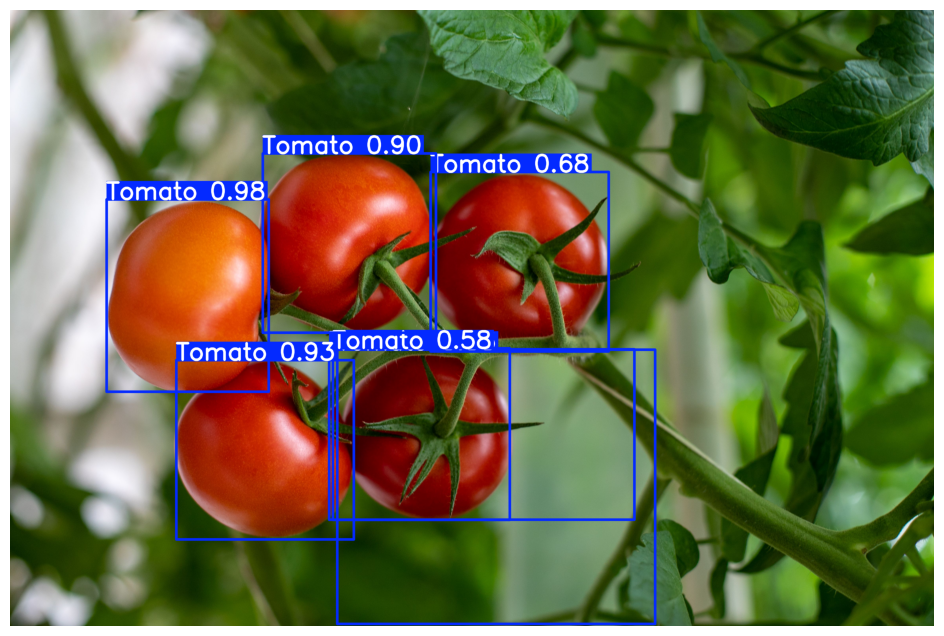

In [ ]:
import matplotlib.pyplot as plt

# 1. Run prediction on image 97
results = model.predict(
    source="/content/97.jpg",
    conf=0.30,
    verbose=True
)[0]

# 2. Print summary and confidence scores
print("Tomatoes detected:", len(results.boxes))

for i, conf in enumerate(results.boxes.conf.tolist(), 1):
    print(f"Tomato {i}: {conf*100:.1f}%")

# 3. Plot and display the annotated image
annotated = results.plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated[:, :, ::-1]) # Convert BGR to RGB for Matplotlib
plt.axis("off")
plt.show()